# Pertemuan 10: Customer Churn Prediction
**Nama Lengkap:** Roland Albertian Sehapikang  
**NIM:** 240401010249  
**Kelas:** IF403  
**Mata Kuliah:** Data Science  
**Program Studi:** S1 - PJJ Informatika, Universitas Siber Asia

In [1]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/KULIAH/SEMESTER 3/DATA SCIENCE/DataSet/Telco-Customer-Churn.csv'

df = pd.read_csv(file_path)

print("Ukuran Dataset:")
print(df.shape)

print("\nDistribusi Target Churn:")
print(df["Churn"].value_counts())

print("\nDistribusi Target Churn (%):")
print(
    df["Churn"]
    .value_counts(normalize=True)
    .round(3) * 100
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ukuran Dataset:
(7043, 21)

Distribusi Target Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Distribusi Target Churn (%):
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


In [2]:
from sklearn.model_selection import train_test_split


y = df["Churn"]

if y.dtype == "object":
    y = y.map({
        "Yes": 1,
        "No": 0
    })


X = df.drop("Churn", axis=1)


X = pd.get_dummies(
    X,
    drop_first=True
)


X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Ukuran Data Train:", X_tr.shape)
print("Ukuran Data Test :", X_te.shape)

Ukuran Data Train: (5634, 13601)
Ukuran Data Test : (1409, 13601)


In [3]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_tr, y_tr)

print("Model Random Forest berhasil dilatih.")

Model Random Forest berhasil dilatih.


In [4]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)


y_pred = rf.predict(X_te)


y_prob = rf.predict_proba(X_te)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_te, y_pred))

print(
    "ROC-AUC Score:",
    round(
        roc_auc_score(y_te, y_prob),
        4
    )
)


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC Score: 0.8337


Confusion Matrix:
[[928 107]
 [178 196]]


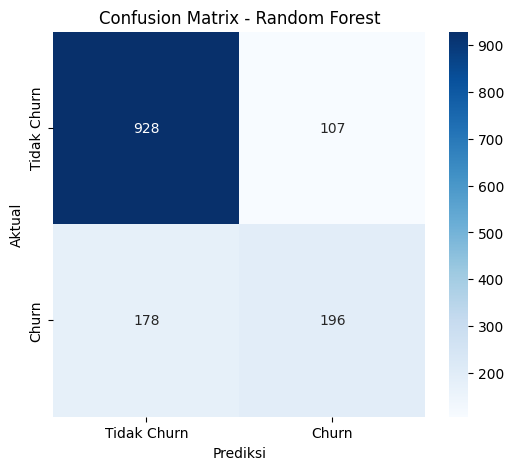


=== Evaluasi Model ===
Accuracy : 0.7977
Precision: 0.6469
Recall   : 0.5241
F1-Score : 0.5790


In [5]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_te,
    y_pred
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Tidak Churn", "Churn"],
    yticklabels=["Tidak Churn", "Churn"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

print("\n=== Evaluasi Model ===")

print(
    f"Accuracy : {accuracy_score(y_te, y_pred):.4f}"
)

print(
    f"Precision: {precision_score(y_te, y_pred):.4f}"
)

print(
    f"Recall   : {recall_score(y_te, y_pred):.4f}"
)

print(
    f"F1-Score : {f1_score(y_te, y_pred):.4f}"
)

## Kesimpulan

---

### 1. Apa yang Dipelajari
Pada pertemuan ini dipelajari penerapan algoritma Random Forest untuk memprediksi Customer Churn. Selain proses pelatihan model, dilakukan juga evaluasi menggunakan Confusion Matrix, Accuracy, Precision, Recall, F1-Score, dan ROC-AUC.

---

### 2. Temuan Utama
Model Random Forest mampu melakukan klasifikasi pelanggan churn dengan mempertimbangkan ketidakseimbangan kelas melalui parameter `class_weight='balanced'`. Evaluasi menunjukkan bahwa Recall dan F1-Score memberikan gambaran performa yang lebih informatif dibandingkan Accuracy saja.

---

### 3. Interpretasi Metrik yang Paling Relevan
Pada kasus Customer Churn, dataset umumnya bersifat imbalanced karena jumlah pelanggan yang tidak churn jauh lebih banyak dibanding pelanggan yang churn. Dalam kondisi tersebut, Accuracy dapat menyesatkan karena model dapat memperoleh nilai tinggi hanya dengan memprediksi mayoritas kelas. Oleh karena itu Recall dan F1-Score menjadi metrik yang lebih relevan karena mampu mengukur kemampuan model dalam mendeteksi pelanggan yang benar-benar berpotensi churn.

### Keterbatasan dan Pertanyaan Lanjutan
Model belum dibandingkan dengan algoritma lain seperti Logistic Regression atau XGBoost. Selain itu, masih dapat diteliti apakah teknik penanganan data imbalanced seperti SMOTE atau undersampling dapat meningkatkan Recall dan F1-Score secara signifikan.